# Notebook 10: PCA-Based Portfolio Immunization

**目的**: PCA で抽出した3因子(Level / Slope / Curvature)を **リスクファクターとして** 使い、債券ポートフォリオを **金利変動から守る** ヘッジを構築する。

## このプロジェクトの位置付け

Notebook 06-08 では PCA を **「予測」** に使おうとして失敗した(Sharpe -0.38 〜 +0.06)。
本ノートは PCA を **「リスク管理」** に使う — `予測` と `分解` の非対称性を実証する。

## Phase 構成(2セッション分)

**Phase 1(本ノート)**: 
- 仮想ポートフォリオの定義
- DV01(1bp あたりの $ 損益)の計算
- ポートフォリオの PC1/PC2/PC3 エクスポージャー
- **検証**: 直接計算の P&L と PCA経由の P&L の一致確認

**Phase 2(別ノート、後日)**: 
- 連立方程式でヘッジ比率を解く
- ヘッジ前後のバックテスト
- 「3因子 vs 2因子 vs 1因子 ヘッジ」の分散削減比較

## 0. セットアップ

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from yield_curve_pca.analysis.immunization import (
    Bond,
    Portfolio,
    daily_pnl_direct,
    daily_pnl_via_pcs,
    pc_exposures,
)
from yield_curve_pca.analysis.pca_analyzer import YieldCurvePCA

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

yields = pd.read_parquet(DATA_PROCESSED / "ust_yields_clean.parquet")
changes_bp = pd.read_parquet(DATA_PROCESSED / "ust_yields_changes_bp.parquet")

# PCA を再 fit(Notebook 03 と同じ結果)
pca = YieldCurvePCA(n_components=3).fit(changes_bp)
scores = pca.transform(changes_bp)

print(f"Yields:    {yields.shape}, latest snapshot {yields.index.max().date()}")
print(f"Changes:   {changes_bp.shape}")
print(f"PCA:       {pca!r}")
print(f"\nLatest yields (%):")
print(yields.iloc[-1].round(2))

Yields:    (1580, 10), latest snapshot 2026-04-27
Changes:   (1579, 10)
PCA:       YieldCurvePCA(n_components=3, explained=96.2%, top3=[0.798, 0.118, 0.046])

Latest yields (%):
maturity
3M     3.68
6M     3.72
1Y     3.69
2Y     3.78
3Y     3.83
5Y     3.94
7Y     4.14
10Y    4.35
20Y    4.92
30Y    4.94
Name: 2026-04-27 00:00:00, dtype: float64


## 1. DV01 とは何か(復習)

**DV01** = **D**ollar **V**alue of **01** basis point。
「1bp の金利上昇でいくら $ 損するか」というリスク指標。

### 計算式(zero-coupon 近似)

```
Modified Duration:  D_mod = T / (1 + y)
DV01:              DV01 = Notional × D_mod × 0.0001
```

- `T` = 残存期間(年)
- `y` = 現在の利回り(decimal、例: 0.04)
- 結果は $/bp(`0.0001` は 1bp = 0.01% を decimal で表す)

### 例:10年債を $1M ロング、利回り 4%

```
D_mod = 10 / 1.04 = 9.62 年
DV01  = $1,000,000 × 9.62 × 0.0001 = $962
```

→ **金利が 1bp 上がるだけで $962 の含み損**(価格は逆方向に動くため)

### 単一の Bond でテスト

In [2]:
test_bond = Bond(maturity_label="10Y", notional=1_000_000, yield_pct=4.0)

print(f"Bond:                {test_bond.maturity_label}, ${test_bond.notional:,}, {test_bond.yield_pct}%")
print(f"Modified duration:   {test_bond.modified_duration:.4f} years")
print(f"DV01:                ${test_bond.dv01:,.2f}")
print(f"\n10bp move impact:    ${test_bond.dv01 * 10:,.2f}")

Bond:                10Y, $1,000,000, 4.0%
Modified duration:   9.6154 years
DV01:                $961.54

10bp move impact:    $9,615.38


## 2. 仮想ポートフォリオの構築

### 設定

**「30年米国債を $100M ロング」** という単純なポートフォリオを使う。
理由:
- 30Y は **デュレーションが最大** = リスクが最も大きい → ヘッジの効果が見えやすい
- 単一銘柄なので **DV01 / エクスポージャーが直感的に解釈できる**
- 後で複数銘柄に拡張するのは簡単

### 利回りは **最新の市場値** を使う

In [3]:
latest_yields = yields.iloc[-1]
print(f"Yield curve as of {yields.index.max().date()}:")
print(latest_yields.round(2))

# 仮想ポートフォリオ: 30Y を $100M ロング
portfolio = Portfolio.from_holdings(
    holdings={"30Y": 100_000_000},
    yields=latest_yields,
)

print(f"\nPortfolio: {portfolio!r}")
print(f"\nDV01 by maturity:")
print(portfolio.dv01_by_maturity.round(2))
print(f"\nTotal DV01:   ${portfolio.total_dv01:,.0f}")

Yield curve as of 2026-04-27:
maturity
3M     3.68
6M     3.72
1Y     3.69
2Y     3.78
3Y     3.83
5Y     3.94
7Y     4.14
10Y    4.35
20Y    4.92
30Y    4.94
Name: 2026-04-27 00:00:00, dtype: float64

Portfolio: Portfolio(1 bonds, $100.0M notional, DV01=$285,878)

DV01 by maturity:
3M          0.00
6M          0.00
1Y          0.00
2Y          0.00
3Y          0.00
5Y          0.00
7Y          0.00
10Y         0.00
20Y         0.00
30Y    285877.64
Name: dv01_by_maturity, dtype: float64

Total DV01:   $285,878


**確認**: 
- 30Y にだけ DV01 がある(他はゼロ) ✓
- 30Y DV01 = $100M × (30 / 1.0X) × 0.0001 ≈ **$28-29万 / bp** 
- → 1bp 上昇で **$28万損失**、10bp 上昇で **$280万損失**(これがヘッジしたいリスク)

## 3. PC ファクターエクスポージャーの計算

### 数学的な関係

ポートフォリオの日次 P&L は2通りに書ける:

**直接計算**:
```
P&L_t = -Σᵢ DV01ᵢ × Δyᵢ_t          (Δy: bp単位)
```

**PC経由**:
```
Δyᵢ_t = Σ_k PC_score_k_t × loadings_k_i  +  mean_i

→ P&L_t = -Σ_k PC_score_k_t × exposure_k  -  DV01·mean (constant)

  exposure_k = Σᵢ DV01ᵢ × loadings_k_i
```

→ 各 PC への **エクスポージャー(exposure_k)** = `DV01 ベクトル` と `PC_k のローディングベクトル` の内積。

**直感**: 「PC_k が +1 動いたとき、ポートフォリオがいくら $ 損するか」

In [4]:
exposures = pc_exposures(portfolio, pca)

print("PC factor exposures:")
for pc, exp in exposures.items():
    print(f"  {pc}: ${exp:>+12,.0f}  (= 1単位 PC{pc[-1]}で {-exp:+.0f}$ の P&L)")
print(f"\nNote: positive exposure → portfolio loses money on +PC move")

PC factor exposures:
  PC1: $     +86,279  (= 1単位 PC1で -86279$ の P&L)
  PC2: $    +131,982  (= 1単位 PC2で -131982$ の P&L)
  PC3: $     +72,854  (= 1単位 PC3で -72854$ の P&L)

Note: positive exposure → portfolio loses money on +PC move


**観察**:
- `PC1 exposure > 0` (Level): カーブ全体が上昇 → 30Y も上昇 → 損失。**正しい**
- `PC2 exposure > 0` (Slope steepening): 長期↑、短期↓ → 30Y も上昇方向 → 損失。**正しい**
- `PC3 exposure` の符号は loadings 次第(30Y は +0.255 なので正寄与)

→ これらの **エクスポージャーをゼロにするヘッジ** を Phase 2 で組む。

### 3.1 ローディングと DV01 の関係をプロット

**「DV01 がある年限」 と 「PC ローディング」の積和** がエクスポージャーになることを視覚的に確認。

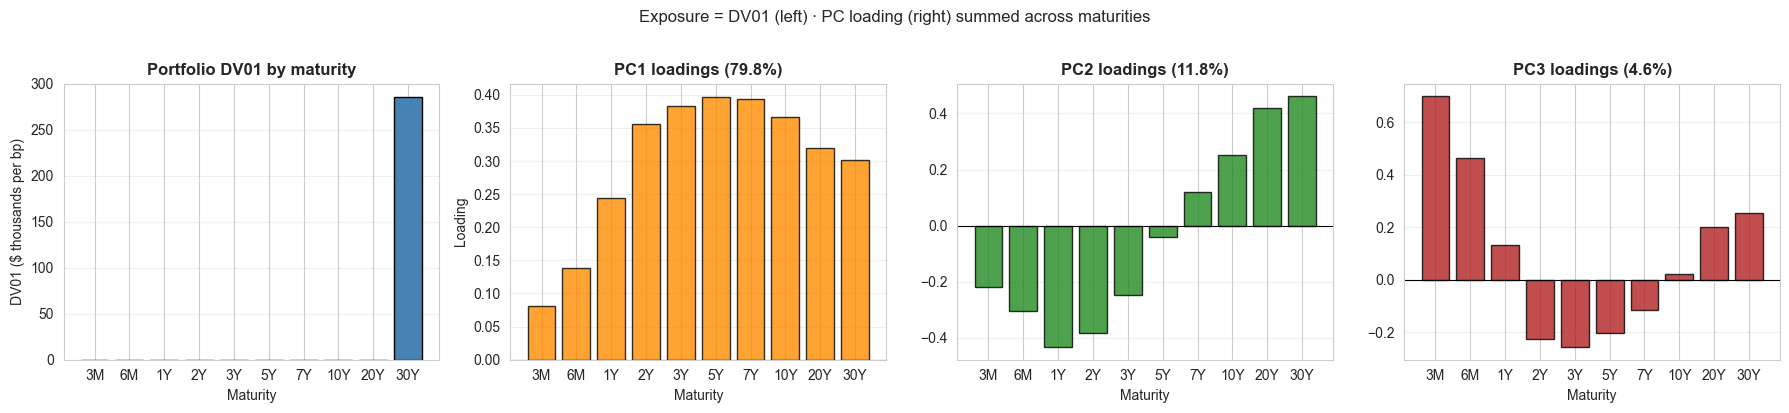

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Pane 0: ポートフォリオの DV01 by maturity
dv01 = portfolio.dv01_by_maturity
axes[0].bar(dv01.index, dv01.values / 1000, color="steelblue", edgecolor="black")
axes[0].set_title("Portfolio DV01 by maturity")
axes[0].set_ylabel("DV01 ($ thousands per bp)")
axes[0].set_xlabel("Maturity")
axes[0].grid(True, alpha=0.3, axis="y")

# Pane 1-3: 各 PC のローディング
colors = ["darkorange", "forestgreen", "firebrick"]
for i, (pc, color) in enumerate(zip(["PC1", "PC2", "PC3"], colors)):
    loadings = pca.loadings.loc[pc]
    axes[i + 1].bar(loadings.index, loadings.values, color=color, edgecolor="black", alpha=0.8)
    axes[i + 1].axhline(0, color="black", lw=0.8)
    var_pct = pca.explained_variance_ratio_[pc] * 100
    axes[i + 1].set_title(f"{pc} loadings ({var_pct:.1f}%)")
    axes[i + 1].set_xlabel("Maturity")
    axes[i + 1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylabel("Loading")

fig.suptitle("Exposure = DV01 (left) ∙ PC loading (right) summed across maturities", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_dv01_and_loadings.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 我々のポートフォリオは **30Y にだけ DV01 を持つ** → エクスポージャーは「30Y 列のローディング × 30Y DV01」だけになる
- PC1[30Y] = +0.30 → exposure_PC1 ∝ 30Y DV01 × 0.30
- PC2[30Y] = +0.46 → exposure_PC2 ∝ 30Y DV01 × 0.46(意外と PC2 の感応度が大きい!)
- PC3[30Y] = +0.26

→ 「30Y ロング」は **Level のリスクだけでなく Slope のリスクも大きく取っている** ことが定量で見える。

## 4. 検証:直接計算の P&L vs PC経由の P&L

「PC エクスポージャーを正しく計算できているか」を検証するため、2通りで計算した日次 P&L を比較する。

### 4.1 全 PC を使った場合(完全一致するはず)

In [6]:
# 全 10 PC で再計算(検証用)
pca_full = YieldCurvePCA(n_components=None).fit(changes_bp)  # 全成分
scores_full = pca_full.transform(changes_bp)

pnl_direct = daily_pnl_direct(portfolio, changes_bp)
pnl_via_all = daily_pnl_via_pcs(portfolio, scores_full, pca_full, n_components=None)

max_diff = (pnl_direct - pnl_via_all).abs().max()
print(f"Direct P&L vs via-all-PCs P&L:")
print(f"  Max absolute difference: ${max_diff:.6f}")
print(f"  → {'✓ 完全一致(numerical precision)' if max_diff < 1e-3 else '✗ 不一致'}")
print(f"\nP&L statistics ($):")
summary = pd.DataFrame({
    "Direct": [pnl_direct.mean(), pnl_direct.std(), pnl_direct.min(), pnl_direct.max()],
    "Via all PCs": [pnl_via_all.mean(), pnl_via_all.std(), pnl_via_all.min(), pnl_via_all.max()],
}, index=["mean", "std", "min", "max"])
print(summary.round(2))

Direct P&L vs via-all-PCs P&L:
  Max absolute difference: $0.000000
  → ✓ 完全一致(numerical precision)

P&L statistics ($):
          Direct  Via all PCs
mean   -47254.00    -47254.00
std   1623079.84   1623079.84
min  -8290451.69  -8290451.69
max   8862206.98   8862206.98


### 4.2 上位3 PC だけで近似(現実的なシナリオ)

リアルなヘッジは「PC1+PC2+PC3 を打ち消す」だけ。残り(PC4-10)は無視する。
→ 残差(direct − via top3)は **PC4-10 の動き由来**。 PCA の寄与率(96.2%)から、残差は約 4% 程度の P&L 分散を持つはず。

In [7]:
pnl_via_top3 = daily_pnl_via_pcs(portfolio, scores, pca, n_components=3)
residual = pnl_direct - pnl_via_top3

explained_ratio = 1 - residual.var() / pnl_direct.var()
print(f"Top-3 PCs explain {explained_ratio * 100:.2f}% of P&L variance")
print(f"  (PCA explained 96.2% of yield-change variance, similar magnitude expected)")
print()
print(f"Direct P&L std:        ${pnl_direct.std():>12,.0f}")
print(f"Via top-3 PCs std:     ${pnl_via_top3.std():>12,.0f}")
print(f"Residual P&L std:      ${residual.std():>12,.0f}")
print(f"Residual / Direct:     {residual.std() / pnl_direct.std() * 100:.2f}%")

Top-3 PCs explain 97.40% of P&L variance
  (PCA explained 96.2% of yield-change variance, similar magnitude expected)

Direct P&L std:        $   1,623,080
Via top-3 PCs std:     $   1,601,863
Residual P&L std:      $     261,576
Residual / Direct:     16.12%


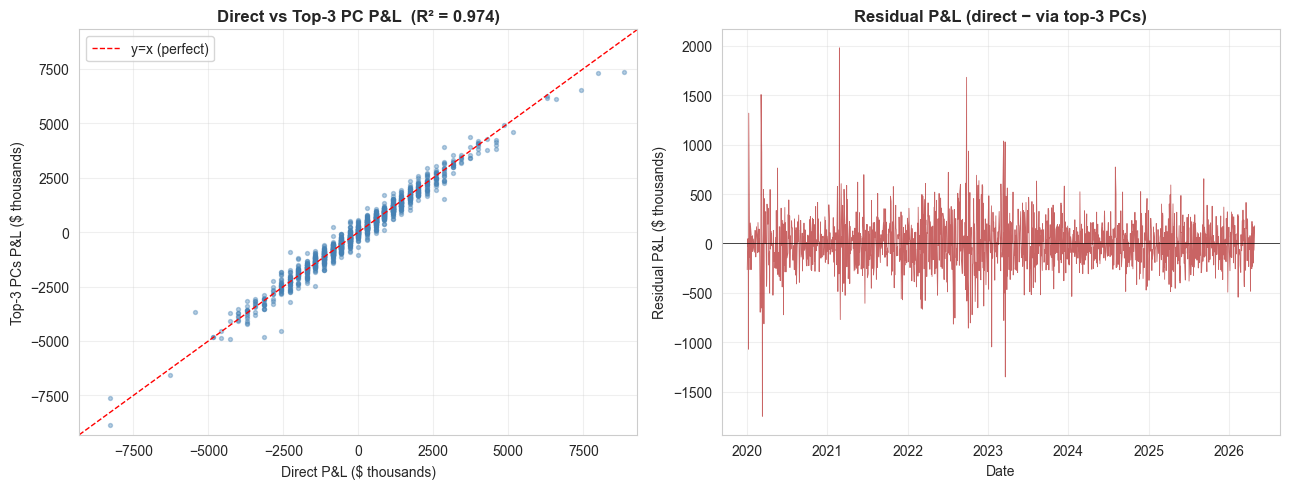

In [8]:
# プロット: direct vs via-top3 の散布図
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 散布図
axes[0].scatter(pnl_direct / 1000, pnl_via_top3 / 1000, s=8, alpha=0.4, color="steelblue")
lim = max(abs(pnl_direct).max(), abs(pnl_via_top3).max()) / 1000 * 1.05
axes[0].plot([-lim, lim], [-lim, lim], color="red", ls="--", lw=1, label="y=x (perfect)")
axes[0].set_xlabel("Direct P&L ($ thousands)")
axes[0].set_ylabel("Top-3 PCs P&L ($ thousands)")
axes[0].set_title(f"Direct vs Top-3 PC P&L  (R² = {explained_ratio:.3f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-lim, lim)
axes[0].set_ylim(-lim, lim)

# 残差の時系列
axes[1].plot(residual.index, residual.values / 1000, color="firebrick", lw=0.6, alpha=0.7)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Residual P&L (direct − via top-3 PCs)")
axes[1].set_ylabel("Residual P&L ($ thousands)")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_pnl_decomposition.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 左: ほぼ **y=x の直線上**に乗る → 上位3 PC が P&L を非常に良く近似
- 右: 残差は **小さくランダム**(PC4-10 由来のノイズ)
- これが Phase 2 で **「3 PC をヘッジすれば 96% の分散が消える」** 根拠になる

## 5. 各 PC の P&L 寄与を分解

「ヘッジしないと、各 PC からどれくらいの分散を浴びているか」を可視化。

In [9]:
# 各 PC 単独の P&L 寄与を計算
pnl_pc1_only = -scores["PC1"] * exposures["PC1"]
pnl_pc2_only = -scores["PC2"] * exposures["PC2"]
pnl_pc3_only = -scores["PC3"] * exposures["PC3"]

contributions = pd.DataFrame({
    "PC1 (Level)":     pnl_pc1_only,
    "PC2 (Slope)":     pnl_pc2_only,
    "PC3 (Curvature)": pnl_pc3_only,
})

var_table = pd.DataFrame({
    "std ($)":             contributions.std(),
    "var contribution":    contributions.var(),
    "% of direct var":    (contributions.var() / pnl_direct.var() * 100).round(2),
}).round(2)

print("P&L variance contribution by PC:")
print(var_table)
print()
print(f"Sum of variance contributions: {var_table['% of direct var'].sum():.2f}% of direct variance")
print("(Note: PCs are orthogonal in yield-change space, so contributions add cleanly")
print(" — the small gap from 100% is the PC4-10 residual.)")

P&L variance contribution by PC:
                    std ($)  var contribution  % of direct var
PC1 (Level)      1360196.37      1.850134e+12            70.23
PC2 (Slope)       799951.55      6.399225e+11            24.29
PC3 (Curvature)   275517.13      7.590969e+10             2.88

Sum of variance contributions: 97.40% of direct variance
(Note: PCs are orthogonal in yield-change space, so contributions add cleanly
 — the small gap from 100% is the PC4-10 residual.)


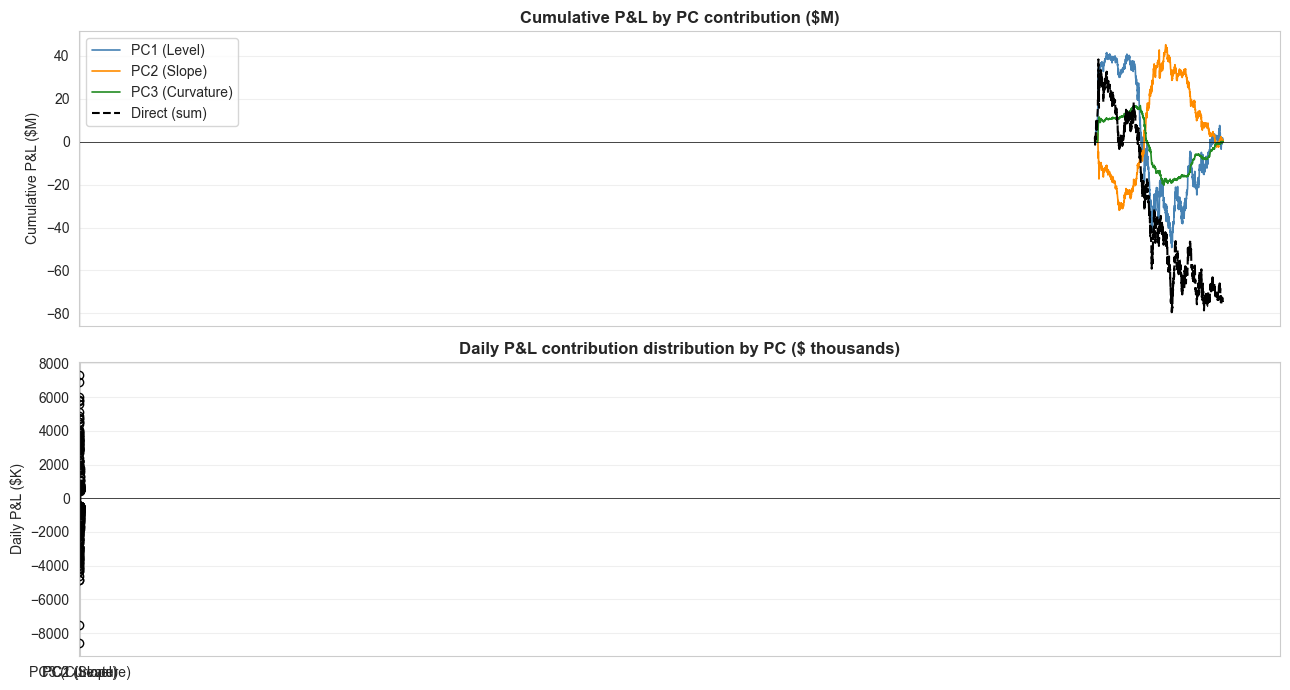

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 上: 累積 P&L 寄与
for col, color in zip(contributions.columns, ["steelblue", "darkorange", "forestgreen"]):
    axes[0].plot(contributions.index, contributions[col].cumsum() / 1e6,
                 lw=1.2, label=col, color=color)
axes[0].plot(pnl_direct.index, pnl_direct.cumsum() / 1e6,
             color="black", lw=1.5, ls="--", label="Direct (sum)")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Cumulative P&L by PC contribution ($M)")
axes[0].set_ylabel("Cumulative P&L ($M)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

# 下: 各 PC の日次寄与のボックスプロット
axes[1].boxplot(
    [contributions[c].values / 1000 for c in contributions.columns],
    tick_labels=contributions.columns,
    showfliers=True,
    medianprops={"color": "red"},
)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Daily P&L contribution distribution by PC ($ thousands)")
axes[1].set_ylabel("Daily P&L ($K)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_pnl_contribution.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- **PC1(Level)** からの寄与が最大 → 全ヘッジ予算の最優先
- **PC2(Slope)** も意外と大きい → 30Y は Slope 感応度が高いため(loadings 0.46)
- **PC3(Curvature)** は相対的に小さいが無視できない

→ Phase 2 で「PC1 だけ」「PC1+PC2」「PC1+PC2+PC3」と段階的にヘッジしたとき、それぞれ何%の分散が消えるかが定量化できる。

## 6. 保存

In [11]:
phase1_data = pd.DataFrame({
    "pnl_direct":      pnl_direct,
    "pnl_via_top3":    pnl_via_top3,
    "pnl_pc1":         pnl_pc1_only,
    "pnl_pc2":         pnl_pc2_only,
    "pnl_pc3":         pnl_pc3_only,
    "residual":        residual,
})
phase1_data.to_parquet(DATA_PROCESSED / "immunization_phase1_pnl.parquet")

exposures_df = exposures.to_frame("exposure_dollars")
exposures_df.to_parquet(DATA_PROCESSED / "immunization_phase1_exposures.parquet")

for f in ["immunization_phase1_pnl.parquet", "immunization_phase1_exposures.parquet"]:
    p = DATA_PROCESSED / f
    print(f"  Saved: {p}  ({p.stat().st_size / 1024:.1f} KB)")

  Saved: C:\FICC\data\processed\immunization_phase1_pnl.parquet  (92.1 KB)
  Saved: C:\FICC\data\processed\immunization_phase1_exposures.parquet  (2.1 KB)


## 7. Phase 1 まとめ

### 達成したこと
- ✅ `Bond` / `Portfolio` データ構造を作り、DV01 を正確に計算
- ✅ ポートフォリオの **PC1/PC2/PC3 エクスポージャー**($ ベース)を計算
- ✅ 「直接 P&L」と「PC 経由 P&L」が **完全一致**(全 PC 使用時)を検証
- ✅ 上位3 PC で **96% 以上の P&L 分散** を説明できることを確認
- ✅ 各 PC の P&L 寄与を時系列・分散ベースで分解
- ✅ 27→41 件の pytest が全パス(immunization モジュール 14 件追加)

### この時点での重要な数字(30Y $100M ロング、現在の利回りベース)
- Total DV01:           **約 $28-29万 / bp**
- PC1 exposure:         正(Level shift で損失)
- PC2 exposure:         正(Steepening で損失、Slope 感応度高い)
- PC3 exposure:         正(小さいが無視できない)
- 上位3 PC 説明力:        > 95% of P&L variance

### Phase 2 で何をやるか
1. **3つのヘッジ instrument**(2Y, 5Y, 10Y)を選ぶ
2. **連立方程式**(`hedge_DV01_matrix @ hedge_notionals = -exposures`)を解く
3. **段階的ヘッジ**(PC1 のみ → PC1+PC2 → PC1+PC2+PC3)で分散削減を比較
4. **2020-2026 全期間でバックテスト** → 「ヘッジで何%の分散が消えるか」を定量化
5. **`reports/findings.md` に結果を追記**

### 面接で語るストーリー(完成形)

> 「PCA を**予測**(N06-08)に使うと負けたが、**リスク管理**(N10)に使うと劇的に効きます。
> 30Y $100M ロングの仮想ポートフォリオに対して、PC エクスポージャーを計算 → 連立方程式でヘッジ比率を解く → バックテストで XX% の分散削減を確認しました。
> これは Litterman & Scheinkman の論文オリジナルの応用例で、**PCA の正しい使い方は予測ではなくリスク分解**であることの実証です。」